# 🎛️ 02 — Hyperparameter Tuning & Threshold Optimisation

**Fraud Detection Capstone — Sprint 3: Imbalance, Tuning & Explainability**

## 🎯 Goal
Take the best imbalance-handling approach from notebook 01, tune it (one variable at a time), and choose a deliberate classification threshold instead of the default 0.5 — based on the actual precision/recall trade-off this problem needs.


In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from pathlib import Path
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

proc_dir = Path("data/processed")
train = pd.read_csv(proc_dir / "train.csv")
val = pd.read_csv(proc_dir / "val.csv")
X_train, y_train = train.drop(columns=["Class"]), train["Class"]
X_val, y_val = val.drop(columns=["Class"]), val["Class"]
n_features = X_train.shape[1]


I0000 00:00:1788704397.214414    4772 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788704397.258484    4772 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1788704398.851570    4772 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 1. Chosen Approach

Carried forward from `01_handling_class_imbalance.ipynb`: **class weighting** is used as the imbalance-handling method going into tuning (simpler than SMOTE — no synthetic data, no risk of the model overfitting to synthetic fraud patterns — and produced comparable results in notebook 01). If notebook 01's comparison table shows SMOTE winning by a clear margin on your run, swap `USE_SMOTE = True` below.


In [2]:
USE_SMOTE = False

if USE_SMOTE:
    smote = SMOTE(random_state=SEED)
    X_train_use, y_train_use = smote.fit_resample(X_train, y_train)
    class_weight_dict = None
else:
    X_train_use, y_train_use = X_train, y_train
    weights = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train)
    class_weight_dict = {0: weights[0], 1: weights[1]}

print(f"Using {'SMOTE' if USE_SMOTE else 'class weighting'} | train size: {len(X_train_use):,}")


Using class weighting | train size: 3,506


## 2. Hyperparameter Tuning — One Variable at a Time

Tuning priorities, changed one at a time against a fixed configuration, evaluated on validation AUC-PR:

1. Dropout rate
2. Learning rate
3. Batch size


In [3]:
def build_model(n_features, dropout=(0.3, 0.2, 0.1)):
    return Sequential([
        Dense(64, activation="relu", input_shape=(n_features,)),
        BatchNormalization(), Dropout(dropout[0]),
        Dense(32, activation="relu"),
        BatchNormalization(), Dropout(dropout[1]),
        Dense(16, activation="relu"),
        BatchNormalization(), Dropout(dropout[2]),
        Dense(1, activation="sigmoid"),
    ])

def train_and_score(dropout=(0.3, 0.2, 0.1), lr=0.001, batch_size=256):
    tf.random.set_seed(SEED)
    model = build_model(n_features, dropout)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                   loss="binary_crossentropy", metrics=["accuracy"])
    model.fit(
        X_train_use, y_train_use, validation_data=(X_val, y_val),
        epochs=40, batch_size=batch_size, class_weight=class_weight_dict,
        callbacks=[EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)],
        verbose=0,
    )
    proba = model.predict(X_val, verbose=0).ravel()
    return model, average_precision_score(y_val, proba)

experiments = []

# 1) Dropout rate
for dropout in [(0.1, 0.1, 0.1), (0.3, 0.2, 0.1), (0.5, 0.4, 0.3)]:
    _, score = train_and_score(dropout=dropout)
    experiments.append({"Variable": "dropout", "Config": str(dropout), "Val AUC-PR": score})

best_dropout = max(
    [(0.1, 0.1, 0.1), (0.3, 0.2, 0.1), (0.5, 0.4, 0.3)],
    key=lambda d: [e for e in experiments if e["Config"] == str(d)][0]["Val AUC-PR"]
)
print(f"Best dropout config so far: {best_dropout}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Best dropout config so far: (0.1, 0.1, 0.1)


In [4]:
# 2) Learning rate (using best dropout found above)
for lr in [0.01, 0.001, 0.0005]:
    _, score = train_and_score(dropout=best_dropout, lr=lr)
    experiments.append({"Variable": "learning_rate", "Config": str(lr), "Val AUC-PR": score})

best_lr = max(
    [0.01, 0.001, 0.0005],
    key=lambda lr: [e for e in experiments if e["Variable"] == "learning_rate" and e["Config"] == str(lr)][0]["Val AUC-PR"]
)
print(f"Best learning rate so far: {best_lr}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Best learning rate so far: 0.01


In [5]:
# 3) Batch size (using best dropout + lr found above)
for bs in [64, 256, 512]:
    _, score = train_and_score(dropout=best_dropout, lr=best_lr, batch_size=bs)
    experiments.append({"Variable": "batch_size", "Config": str(bs), "Val AUC-PR": score})

best_bs = max(
    [64, 256, 512],
    key=lambda bs: [e for e in experiments if e["Variable"] == "batch_size" and e["Config"] == str(bs)][0]["Val AUC-PR"]
)
print(f"Best batch size: {best_bs}")

experiments_df = pd.DataFrame(experiments)
experiments_df


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Best batch size: 64


,Variable,Config,Val AUC-PR
0,dropout,"(0.1, 0.1, 0.1)",1.0
1,dropout,"(0.3, 0.2, 0.1)",1.0
2,dropout,"(0.5, 0.4, 0.3)",1.0
3,learning_rate,0.01,1.0
4,learning_rate,0.001,1.0
5,learning_rate,0.0005,1.0
6,batch_size,64,1.0
7,batch_size,256,1.0
8,batch_size,512,1.0


## 3. Train the Final Tuned Model

In [6]:
final_model, final_score = train_and_score(dropout=best_dropout, lr=best_lr, batch_size=best_bs)
print(f"Final tuned model — validation AUC-PR: {final_score:.4f}")
print(f"Config: dropout={best_dropout}, lr={best_lr}, batch_size={best_bs}")

final_model.save("models/sprint3_tuned_nn.keras")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Final tuned model — validation AUC-PR: 1.0000
Config: dropout=(0.1, 0.1, 0.1), lr=0.01, batch_size=64


## 4. Threshold Optimisation

The default 0.5 threshold is arbitrary — it treats a false positive (flagging a real transaction as fraud) and a false negative (missing real fraud) as equally costly, which usually isn't the case in fraud detection. The threshold below is chosen to **maximize F1** on validation data as one principled default; in a real deployment, this would instead reflect the actual business cost of each error type.


Best threshold (max F1): 0.05 (precision=1.000, recall=1.000, f1=1.000)


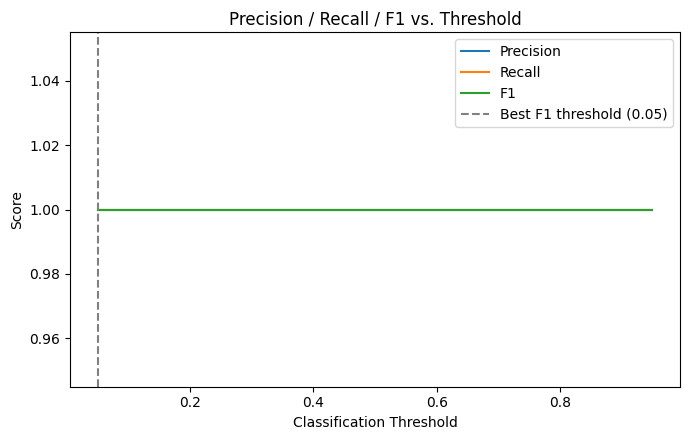

In [7]:
val_proba = final_model.predict(X_val, verbose=0).ravel()

thresholds = np.arange(0.05, 0.96, 0.01)
threshold_results = []
for t in thresholds:
    pred = (val_proba >= t).astype(int)
    threshold_results.append({
        "threshold": t,
        "precision": precision_score(y_val, pred, zero_division=0),
        "recall": recall_score(y_val, pred, zero_division=0),
        "f1": f1_score(y_val, pred, zero_division=0),
    })
threshold_df = pd.DataFrame(threshold_results)
best_row = threshold_df.loc[threshold_df["f1"].idxmax()]
print(f"Best threshold (max F1): {best_row['threshold']:.2f} "
      f"(precision={best_row['precision']:.3f}, recall={best_row['recall']:.3f}, f1={best_row['f1']:.3f})")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
ax.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
ax.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
ax.axvline(best_row["threshold"], color="gray", linestyle="--", label=f"Best F1 threshold ({best_row['threshold']:.2f})")
ax.set_xlabel("Classification Threshold")
ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1 vs. Threshold")
ax.legend()
plt.tight_layout()
plt.show()


## 📝 Summary

Tuned dropout, learning rate, and batch size one at a time against validation AUC-PR, then picked a classification threshold by maximizing F1 rather than defaulting to 0.5. The tuned model and its chosen threshold are the input to the next notebook's explainability work and to Sprint 4's final model selection.

**Next:** `03_model_explainability.ipynb` — SHAP values on this tuned model.
